In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

/tmp/dcs-tmp.u1604520/ipykernel_626726/3682703318.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})

In [3]:
dgp = "bimodal_univariate_gaussian"
# dgp = "contaminated_normal"
trim_epsilon_upto = 0.2

In [4]:
# if dgp == "contaminated_exp":
#     experiment_path = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/cont_exp_mmd/results.csv")

#     robas_path = experiment_path/ "results_robas.csv"
#     robas_df_og = pd.read_csv(robas_path)
#     # agg_df_robas = process(robas_df_og, 'contaminated_exp_old', 0, trim=True)

#     other_path = experiment_path / "results_bas_bdro_mmd.csv"
#     other_df_og = pd.read_csv(other_path)

#     results_df = pd.concat([robas_df_og, other_df_og])
# elif dgp == "bimodal_univariate_gaussian":
df_list = []
# for name in ["bimodal_9010_mmd", "bimodal_9010_bas"]: # 
for name in [ "mvn_bimosal_9010_mmd",  "bimodal_9010_mmd", "mvn_bimodal_9010_bas", "bimodal_9010_bas", "kl_bimodal_9010_bdro", "bdro_mvn_njobs1_9010"]:  # 
# for name in ["cont_normal_9010_mmd", "cont_normal_9010_bas"]:
    df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/{name}/results.csv")))
all_results_df = pd.concat(df_list)

In [5]:
all_results_df["num_observations"].unique(), all_results_df["num_posterior_samples"].unique(), all_results_df["num_likelihood_samples"].unique()

(array([20]), array([90,  1]), array([ 10, 900]))

In [6]:
results_df1 = preprocess_results_df(all_results_df, dgp)
# agg_df1 = get_agg_df(results_df1, ["algorithm", "dgp", "epsilon", "inference"]) 
results_df2 = preprocess_results_df(all_results_df, "bimodal_multivariate_gaussian")
# results_df.head(3)


In [7]:
agg_df1 = get_agg_df(results_df1, ["algorithm", "dgp", "epsilon", "inference"]) #, "contamination"
agg_df2 = get_agg_df(results_df2, ["algorithm", "dgp", "epsilon", "inference"]) #, "contamination"

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function mean at 0x7fe8c0432a20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function std at 0x7fe8c0432b60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function mean at 0x7fe8c0432a20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: Futur

In [8]:
# df_reset = agg_df.reset_index()

# # Define the filtering conditions for each algorithm
# condition = (
#     ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['contamination'] > 0.0) & (df_reset['epsilon'] > 0.4)) |
#     ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 1.0))
# )

# # Negate the condition to keep rows not matching the criteria
# df_trimmed = df_reset[~condition]
# df_trimmed = df_trimmed.set_index(agg_df.index.names) 

In [9]:
df_reset = agg_df1.reset_index()

# Define the filtering conditions for each algorithm
condition = (
    ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['epsilon'] > 1)) |
    ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 1)) 
    # ((df_reset['algorithm'] == 'kl_dro_bas') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_bdro') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_pp') & (df_reset['epsilon'] > 1))
)

# Negate the condition to keep rows not matching the criteria
df_trimmed1 = df_reset[~condition]
df_trimmed1 = df_trimmed1.set_index(agg_df1.index.names) 

In [10]:
df_reset = agg_df2.reset_index()

# Define the filtering conditions for each algorithm
condition = (
    ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['epsilon'] > 1)) |
    ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 1)) 
    # ((df_reset['algorithm'] == 'kl_dro_bas') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_bdro') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_pp') & (df_reset['epsilon'] > 1))
)

# Negate the condition to keep rows not matching the criteria
df_trimmed2 = df_reset[~condition]
df_trimmed2 = df_trimmed2.set_index(agg_df2.index.names) 

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

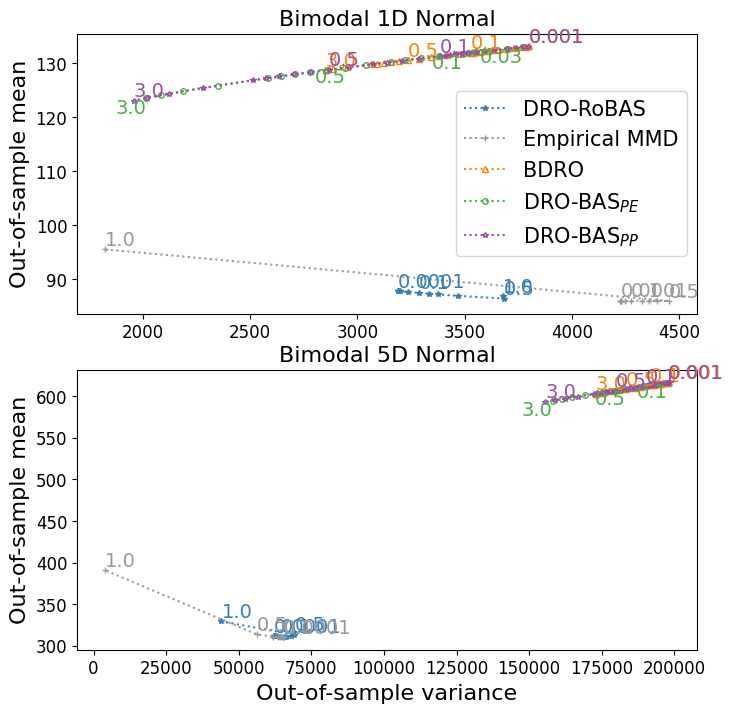

In [19]:
# num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
# cont_list = agg_df.index.get_level_values("contamination").unique().tolist()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
dgp_list = agg_df1.index.get_level_values("dgp").unique().tolist()
dim_list = [1, 5]

nrows = 2#len(dgp_list)
# ncols = len(cont_list)
ncols = 1
# ncols = len(num_observations_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(8, 8))
fig.subplots_adjust(wspace=0.2)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 900
for i, dgp in enumerate(dgp_list):
    # for j, cont in enumerate(cont_list):
    for j, dim in enumerate(dim_list):
        if dim == 1:
            axis_df = df_trimmed1.loc[:, dgp, :, :] #
        elif dim == 5:
            dgp = "bimodal_multivariate_gaussian"
            axis_df = df_trimmed2.loc[:, dgp, :, :] 
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            if algorithm == 'dro_bas_mmd':
                inference = "npl_mmd"
            elif algorithm in ['kl_bdro', 'kl_dro_bas', 'kl_pp']:
                inference = "bayes"
            else:
                inference = "empirical"
            df = axis_df.loc[algorithm, :, inference]
            # for k in range(j, len(cont_list)):
            # # for k in range(j, len(num_observations_list)):
            alpha = 1.0
            is_labelled=True
            #     if j != k:
            #         alpha = 0.2
            #         is_labelled = False
                
            mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend(fontsize=15, loc="center right")
        axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        # axes.set_title("$\eta$" + f"={cont_list[j]}", fontsize=16) # with {NiceNameDGP[dgp]}
        axes[j].tick_params(axis='both', which='major', labelsize=12)
        axes[j].set_title(f"{NiceNameDGP[dgp]}", fontsize=16)
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[dgp]}")
        if j == 1:
            axes[j].set_xlabel("Out-of-sample variance", fontsize=16)
# plt.tight_layout()
fig.savefig("bim.pdf", bbox_inches="tight")

In [12]:
solve_time_df = get_agg_df(results_df2, ["algorithm"])#, "contamination"
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lll}
\toprule
 &  & 0 \\
 & algorithm &  \\
\midrule
\multirow[t]{5}{*}{str_solve_time} & dro_bas_mmd & 262.9432 (31.7199) \\
 & empirical_mmd & 2.1798 (0.3599) \\
 & kl_bdro & 2.6299 (0.2612) \\
 & kl_dro_bas & 1.2446 (0.1922) \\
 & kl_pp & 1.3774 (0.2857) \\
\cline{1-3}
\multirow[t]{5}{*}{str_sample_time} & dro_bas_mmd & 15.8587 (4.8408) \\
 & empirical_mmd & 0.0 (0.0) \\
 & kl_bdro & 0.0104 (0.0004) \\
 & kl_dro_bas & 0.0006 (0.0003) \\
 & kl_pp & 0.001 (0.0004) \\
\cline{1-3}
\bottomrule
\end{tabular}



/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function mean at 0x7fe8c0432a20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function std at 0x7fe8c0432b60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


### Get zoomed-in area

In [20]:
df_list = []
for name in [ "mvn_bimosal_9010_mmd",  "bimodal_9010_mmd"]:  # 
# for name in ["cont_normal_9010_mmd", "cont_normal_9010_bas"]:
    df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/{name}/results.csv")))
all_results_df = pd.concat(df_list)

In [21]:
# results_df1 = preprocess_results_df(all_results_df, dgp)
# agg_df1 = get_agg_df(results_df1, ["algorithm", "dgp", "epsilon", "inference"]) 
results_df = preprocess_results_df(all_results_df, "bimodal_multivariate_gaussian")

In [22]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference"]) #, "contamination"

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function mean at 0x7fe8c0432a20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:222: FutureWarning: The provided callable <function std at 0x7fe8c0432b60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


In [23]:
df_reset = agg_df.reset_index()

# Define the filtering conditions for each algorithm
condition = (
    ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['epsilon'] > 0.5)) |
    ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 0.5)) 
    # ((df_reset['algorithm'] == 'kl_dro_bas') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_bdro') & (df_reset['epsilon'] > 1)) |
    # ((df_reset['algorithm'] == 'kl_pp') & (df_reset['epsilon'] > 1))
)

# Negate the condition to keep rows not matching the criteria
df_trimmed = df_reset[~condition]
df_trimmed = df_trimmed.set_index(agg_df.index.names) 

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

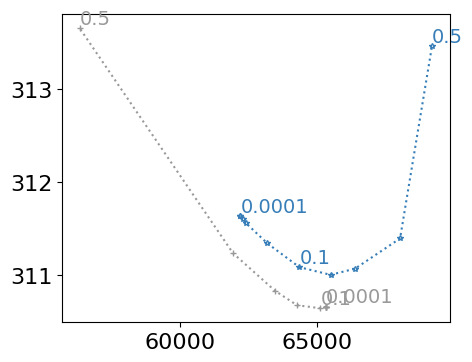

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()
dim_list = [5]

nrows = 1#len(dgp_list)
# ncols = len(cont_list)
ncols = 1
# ncols = len(num_observations_list)


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5, 4))
fig.subplots_adjust(wspace=0.2)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 900
for i, dgp in enumerate(dgp_list):
    # for j, cont in enumerate(cont_list):
    for j, dim in enumerate(dim_list):
        if dim == 1:
            axis_df = df_trimmed.loc[:, dgp, :, :] #
        elif dim == 5:
            dgp = "bimodal_multivariate_gaussian"
            axis_df = df_trimmed.loc[:, dgp, :, :] 
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            if algorithm == 'dro_bas_mmd':
                inference = "npl_mmd"
            elif algorithm in ['kl_bdro', 'kl_dro_bas', 'kl_pp']:
                inference = "bayes"
            else:
                inference = "empirical"
            df = axis_df.loc[algorithm, :, inference]
            # for k in range(j, len(cont_list)):
            # # for k in range(j, len(num_observations_list)):
            alpha = 1.0
            is_labelled=True
            #     if j != k:
            #         alpha = 0.2
            #         is_labelled = False
                
            mean_variance_plot(axes, df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        # if j == 0:
            # axes.legend(fontsize=15, loc="center right")
            # axes.set_ylabel("Out-of-sample mean", fontsize=16)
        # axes.set_title("$\eta$" + f"={cont_list[j]}", fontsize=16) # with {NiceNameDGP[dgp]}
        axes.tick_params(axis='both', which='major', labelsize=16)
        # axes.set_title(f"{NiceNameDGP[dgp]}", fontsize=16)
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[dgp]}")
        # axes[j].set_xlabel("Out-of-sample variance", fontsize=16)
fig.savefig("bim_zoom.pdf", bbox_inches="tight")

Old 

In [5]:
all_gb = results_df.groupby(["algorithm", "contamination", "dgp", "epsilon", "inference"])
all_agg_df = all_gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
})
all_agg_df["out_of_sample_mean"] = all_agg_df["mean_cost"]["mean"]
all_agg_df["out_of_sample_var"] = all_agg_df["var_cost"]["mean"] + all_agg_df["mean_cost"]["var"]
all_agg_df

KeyError: "Column(s) ['mean_cost', 'var_cost'] do not exist"

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_5002/530020784.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


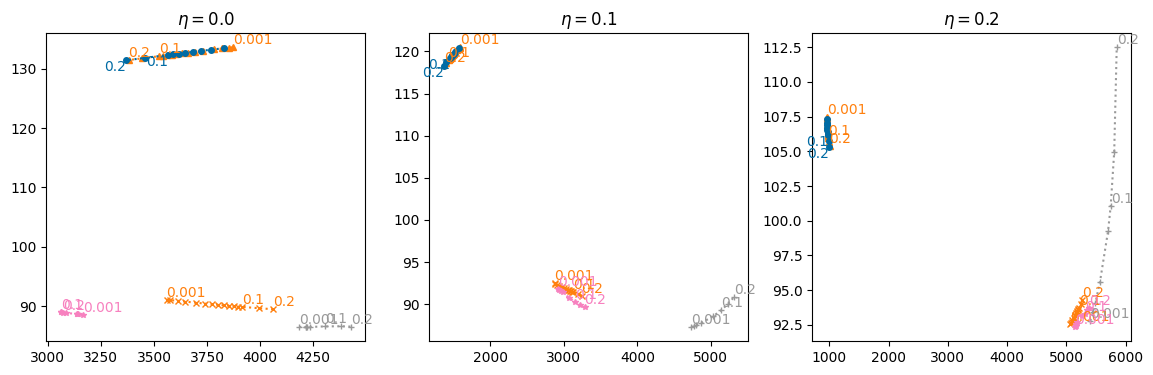

In [63]:
contam_levels = all_agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = all_agg_df.index.get_level_values("dgp").unique().tolist()
fig, axis = plt.subplots(nrows=len(dgp_list), ncols=len(contam_levels), sharex=False, sharey=False, figsize=(14,4))

for i in enumerate(dgp_list):
    for j, contam in enumerate(contam_levels):
        axis_df = all_agg_df.loc[:, contam, dgp, :, :]
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon_upto, inference]
            mean_variance_plot(axis[j], df, **algorithm_inference_style(algorithm, inference), offset=0.0)
        axis[j].set_title('$\eta =$' + str(contam))
fig.savefig(f"/Users/patrick/Experiments/misdro/paper_robas_figures/all_tests_{dgp}.pdf", bbox_inches="tight")
fig.show()

In [64]:
dim = 1

num_observations = results_df["num_observations"].unique()[0]
num_test_observations = results_df["num_test_observations"].unique()[0]
single_test_observation = []
test_50 = []

for (uuid, replication), row in results_df.set_index(["uuid", "replication"]).iterrows():
    contamination = row["contamination"]
    generator = np.random.default_rng(seed=replication)
    # NOTE if contamination is specified, then only contaminate the training samples (not test samples)
    data = sample_dgp(
        dgp, num_observations, dim=dim, contamination=contamination, generator=generator
    )
    data_eval = sample_dgp(
        dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
    )
    x = np.array([float(x) for x in row["solution"].strip('[]').split(',')])
    test_50.append({
        "out_of_sample_cost": np.array2string(newsvendor_cost_cvxpy(x, data_eval).value, max_line_width=np.inf, separator=","),
        "uuid": uuid,
        "replication": replication,
    })
    single_test_observation.append({
        "single_cost": newsvendor_cost_cvxpy(x, np.array([data_eval[0]])).value[0],
        "uuid": uuid,
        "replication": replication,
    })


# for idx, df in results_df.groupby(["algorithm", "contamination", "epsilon", "inference", "replication"]):

#     algorithm, contamination, epsilon, inference, replication = idx
#     generator = np.random.default_rng(seed=replication)
#     # NOTE if contamination is specified, then only contaminate the training samples (not test samples)
#     data = sample_dgp(
#         dgp, num_observations, dim=dim, contamination=contamination, generator=generator
#     )
#     data_eval = sample_dgp(
#         dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
#     )
#     # df = results_df.loc[(results_df["algorithm"] == algorithm) & (results_df["epsilon"] == epsilon) & (results_df["replication"] == replication) & (results_df["contamination"] == contamination)]

#     x = df["solution"].iloc[0]
#     x = np.array([float(x) for x in df["solution"].iloc[0].strip('[]').split(',')])
#     xi = data_eval[0].reshape((1,1))
#     single_test_observation.append({
#         "algorithm": algorithm,
#         "dgp": dgp,
#         "epsilon": epsilon,
#         "inference": inference,
#         "contamination": contamination,
#         "replication": replication,
#         "solution": x,
#         "xi": xi,
#         "objective": newsvendor_cost_cvxpy(x, xi).value[0],
#     })


In [65]:
def get_agg_df(results_df: pd.DataFrame, gb_cols: list[str]):
    """Groupby the given columns then apply summary statistics for each group"""
    assert len(results_df["num_replications"].unique()) == 1
    assert len(results_df["num_test_observations"].unique()) == 1
    num_replications = results_df["num_replications"].unique()[0]
    num_test_observations = results_df["num_test_observations"].unique()[0]
    gb = results_df.groupby(by=gb_cols)
    agg_df = gb.agg(
        out_of_sample_mean = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.mean(np.concatenate(x.values))),
        out_of_sample_var = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.var(np.concatenate(x.values), ddof=1)),
        sum_of_in_group_var = pd.NamedAgg(column="in_group_var", aggfunc=lambda x: float(num_test_observations - 1) / float(num_replications * num_test_observations - 1) * np.sum(x.values)),
        var_of_in_group_mean = pd.NamedAgg(column="in_group_mean", aggfunc=lambda x: float(num_test_observations * (num_replications - 1)) / float(num_replications * num_test_observations - 1) * np.var(x, ddof=1)),
        single_var = pd.NamedAgg(column="single_cost", aggfunc=lambda x: np.var(x, ddof=1)),
    )
    return agg_df

In [66]:
test_50_df = pd.DataFrame(test_50).merge(results_df, on=["uuid", "replication"])
test_50_df = pd.DataFrame(single_test_observation).merge(test_50_df)
preprocessed_50_df = preprocess_results_df(test_50_df, dgp)
agg_df = get_agg_df(preprocessed_50_df, gb_cols=["algorithm", "contamination", "dgp", "epsilon", "inference"])
agg_df


out_of_sample_mean  \
algorithm   contamination dgp                         epsilon inference                       
dro_bas_mmd 0.0           bimodal_univariate_gaussian 0.001   npl_mmd             88.566215   
                                                      0.003   npl_mmd             88.640519   
                                                      0.005   npl_mmd             88.662593   
                                                      0.010   npl_mmd             88.672057   
                                                      0.050   npl_mmd             88.861787   
...                                                                                     ...   
kl_dro_bas  0.2           bimodal_univariate_gaussian 1.000   bayes              101.811035   
                                                      1.500   bayes              100.421071   
                                                      2.000   bayes               99.377467   
                                                      2.500   bayes               98.659948   
                                                      3.000   bayes               98.192407   

                                                                         out_of_sample_var  \
algorithm   contamination dgp                         epsilon inference                      
dro_bas_mmd 0.0           bimodal_univariate_gaussian 0.001   npl_mmd          3165.728450   
                                                      0.003   npl_mmd          3140.395257   
                                                      0.005   npl_mmd          3138.216613   
                                                      0.010   npl_mmd          3137.621567   
                                                      0.050   npl_mmd          3083.147577   
...                                                                                    ...   
kl_dro_bas  0.2           bimodal_univariate_gaussian 1.000   bayes            1173.978845   
                                                      1.500   bayes            1281.256020   
                                                      2.000   bayes            1378.791292   
                                                      2.500   bayes            1454.407129   
                                                      3.000   bayes            1507.045285   

                                                                         sum_of_in_group_var  \
algorithm   contamination dgp                         epsilon inference                        
dro_bas_mmd 0.0           bimodal_univariate_gaussian 0.001   npl_mmd            3157.765231   
                                                      0.003   npl_mmd            3132.393386   
                                                      0.005   npl_mmd            3130.123861   
                                                      0.010   npl_mmd            3129.420525   
                                                      0.050   npl_mmd            3074.501483   
...                                                                                      ...   
kl_dro_bas  0.2           bimodal_univariate_gaussian 1.000   bayes              1162.514433   
                                                      1.500   bayes              1268.594167   
                                                      2.000   bayes              1364.499197   
                                                      2.500   bayes              1438.685937   
                                                      3.000   bayes              1490.361882   

                                                                         var_of_in_group_mean  \
algorithm   contamination dgp                         epsilon inference                         
dro_bas_mmd 0.0           bimodal_univariate_gaussian 0.001   npl_mmd                7.963219   
                                                      0.003   npl_mmd     

In [6]:
contam_levels = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()
fig, axis = plt.subplots(nrows=len(dgp_list), ncols=len(contam_levels), sharex=False, sharey=False, figsize=(14,4))

for i in enumerate(dgp_list):
    for j, contam in enumerate(contam_levels):
        axis_df = agg_df.loc[:, contam, dgp, :, :]
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon_upto, inference]
            mean_variance_plot(axis[j], df, **algorithm_inference_style(algorithm, inference), offset=0.0)
        axis[j].set_title('$\eta =$' + str(contam))
# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_robas_figures/one_test_{dgp}.pdf", bbox_inches="tight")
axis[0].legend()
fig.show()

NameError: name 'agg_df' is not defined

In [7]:
contam_levels = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()
fig, axis = plt.subplots(nrows=len(dgp_list), ncols=len(contam_levels), sharex=False, sharey=False, figsize=(14,4))

for i in enumerate(dgp_list):
    for j, contam in enumerate(contam_levels):
        axis_df = agg_df.loc[:, contam, dgp, :, :]
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon_upto, inference]
            mean_variance_plot(axis[j], df, **algorithm_inference_style(algorithm, inference), offset=0.0, var_col="single_var")
        axis[j].set_title('$\eta =$' + str(contam))
# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_robas_figures/one_test_{dgp}.pdf", bbox_inches="tight")
axis[0].legend()
fig.show()

NameError: name 'agg_df' is not defined

                                                                           out_of_sample_mean  \
algorithm     contamination dgp                         epsilon inference                       
dro_bas_mmd   0.0           bimodal_univariate_gaussian 0.001   npl_mmd             88.566215   
                                                        0.003   npl_mmd             88.640519   
                                                        0.005   npl_mmd             88.662593   
                                                        0.010   npl_mmd             88.672057   
                                                        0.050   npl_mmd             88.861787   
                                                        0.100   npl_mmd             88.939534   
                                                        0.150   npl_mmd             88.937260   
                                                        0.200   npl_mmd             88.898163   
empirical_mmd 0.0           bi

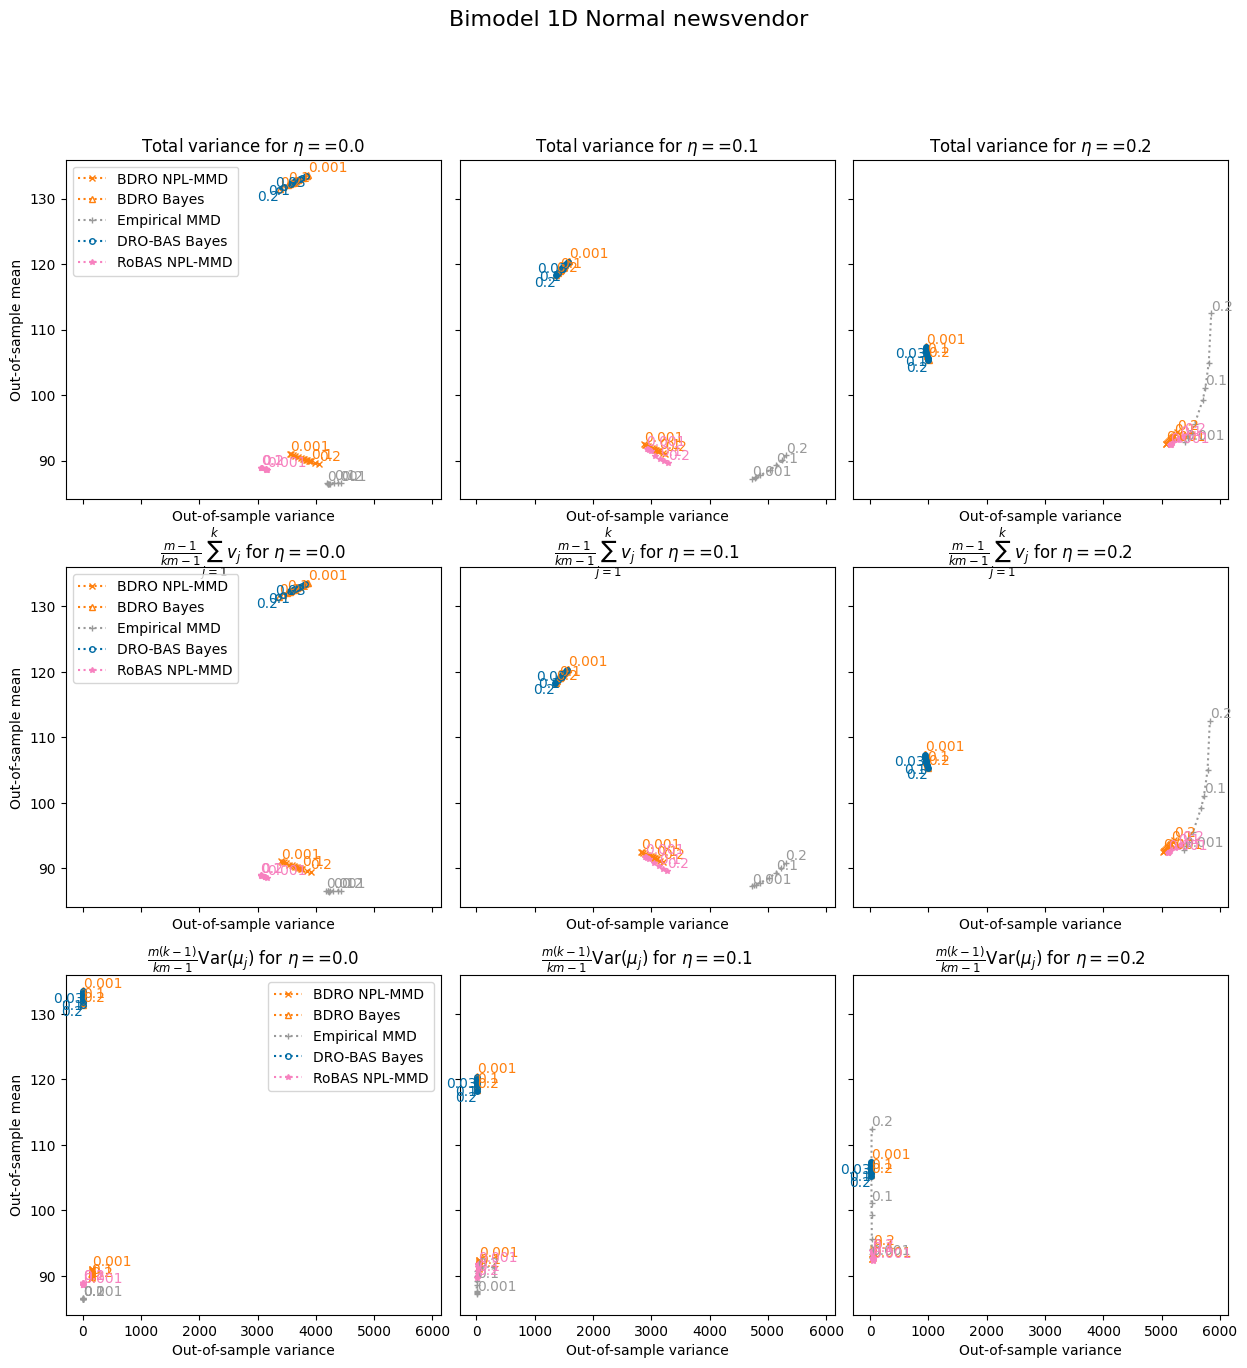

In [70]:
class NiceNameDGP(StrEnum):
    contaminated_exp = "Contaminated Exponential DGP"
    contaminated_exp_old = "Contaminated Exponential DGP (old)"
    exponential = "Exponential DGP"
    normal = "Normal DGP"
    multivariate_normal = "5D Normal DGP"
    truncated_normal = "Truncated Normal DGP"
    DowJones = "DowJones"
    bimodal_univariate_gaussian = "Bimodel 1D Normal"

contam_levels = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(contam_levels)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_row in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, contam in enumerate(contam_levels):
        axis_df = agg_df.loc[:, contam, dgp, :trim_epsilon_upto, :]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            print(axis_df)
            df = axis_df.loc[algorithm, :, :, :, inference]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, inference), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_row)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_row] + " for $\eta =$" + f"={contam}")
        axes[i][j].set_xlabel("Out-of-sample variance")

In [11]:

from typing import Optional
import numpy as np
import scipy as sp
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import upper_triangular_size, DGP_NORMAL_KNOWN_VARIANCE_STD
from mis_dro.likelihood import reconstruct_covariance_from_triu
from mis_dro.dataset import *

def default_prior_params(prior: str, dim: int = 1) -> tuple:
    """Get the default prior parameters"""
    prior_params = ()
    if prior == "gamma":
        alpha_prior, beta_prior = 1, 1
        prior_params = (alpha_prior, beta_prior)
    elif prior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = 0.0, 1.0, 1.0, 1.0
        prior_params = (mu_prior, kappa_prior, alpha_prior, beta_prior)
    elif prior == "normal_inverse_wishart":
        prior_params = normal_inverse_wishart_prior(dim)
    elif prior == "multivariate_normal_known_cov":
        prior_params = (np.zeros(dim), dim+2)
    elif prior == "normal_known_var":
        mu_prior, std_prior = 0.0, DGP_NORMAL_KNOWN_VARIANCE_STD
        prior_params = (mu_prior, std_prior)
    else:
        raise NotImplementedError(f"Prior '{prior}' not implemented.")
    return prior_params

def posterior_predictive_params(posterior: str, posterior_params: tuple) -> np.array:
    """Get the posterior predictive params"""
    if posterior == "normal_gamma":
        # NOTE https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf
        # from eq. (100) of above link:
        mu_posterior, kappa_posterior, alpha_posterior, beta_posterior = posterior_params

        # the scale is rougly equalivalent to the standard deviation
        # in particular, the case where dof = infinity is a Gaussian
        scale = np.sqrt((beta_posterior * (kappa_posterior + 1)) / (alpha_posterior * kappa_posterior))

        dof = 2 * alpha_posterior   # degrees of freedom for student t
        return np.array([[mu_posterior, scale, dof]])

    if posterior == "normal_inverse_wishart":
        # NOTE eq. (3.182), Chapter 3.4.4.3, Murphy (2023) "Probabilistic Machine Learning: Advanced Topics".
        mu_posterior, kappa_posterior, nu_posterior, Psi_posterior = posterior_params
        dim = mu_posterior.shape[0]
        vec_triu_size = int(upper_triangular_size(dim))
        df = nu_posterior - dim + 1     # degrees of freedom

        # store the posterior params in a vectorized vector
        pp_params = np.zeros((1, dim + vec_triu_size + 1))
        idx_triu = np.triu_indices(dim)
        shape = (kappa_posterior + 1)/(kappa_posterior*df) * Psi_posterior
        pp_params[0,:dim] = mu_posterior
        pp_params[0,dim:dim + vec_triu_size] = shape[idx_triu]
        pp_params[0,dim + vec_triu_size] = df
        return pp_params
    
    if posterior == "gamma":
        alpha_posterior, beta_posterior = posterior_params
        shape = alpha_posterior
        scale = beta_posterior
        return np.array([[shape, scale]])
    
    if posterior == "normal_known_var":
        mu_posterior, std_posterior = posterior_params
        return np.array([mu_posterior, std_posterior])


    raise NotImplementedError(f"Posterior predictive not implemented for posterior '{posterior}'.")

def sample_posterior_predictive(
    likelihood: str,
    posterior: str,
    theta_sample: np.ndarray,
    dim: int,
    num_likelihood_samples: int,
    generator: Optional[np.random.Generator] = None,
) -> np.array:
    """Sample from the posterior predictive"""
    if likelihood == "normal" and posterior == "normal_gamma":
        mu, scale, df = theta_sample[0]
        return sp.stats.t.rvs(df, loc=mu, scale=scale, size=(num_likelihood_samples, dim), random_state=generator)
    if likelihood == "multivariate_normal" and posterior == "normal_inverse_wishart":
        pp_params = theta_sample[0]
        loc = pp_params[:dim]
        vec_triu_size = int(upper_triangular_size(dim))
        vec_shape = pp_params[dim: dim + vec_triu_size]
        df = pp_params[dim + vec_triu_size]
        shape = reconstruct_covariance_from_triu(vec_shape, dim)
        samples = sp.stats.multivariate_t.rvs(loc=loc, shape=shape, df=df, size=(1, num_likelihood_samples), random_state=generator)
        return samples
    if likelihood == "exponential" and posterior == "gamma":
        shape, scale = theta_sample[0]
        return sp.stats.lomax.rvs(c=shape, scale=scale, size=(num_likelihood_samples, dim), random_state=generator)
    if likelihood == "normal_known_var" and posterior == "normal_known_var":
        mu, scale = theta_sample
        return sp.stats.norm.rvs(loc=mu, scale=np.sqrt(scale**2+DGP_NORMAL_KNOWN_VARIANCE_STD**2), size=(num_likelihood_samples, dim), random_state=generator)
    raise NotImplementedError()

def sample_posterior(
    posterior: str,
    posterior_params: tuple,
    num_posterior_samples: int,
    generator: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """Sample from the posterior"""
    if posterior == "gamma":
        alpha_post, beta_post = posterior_params
        return sp.stats.gamma.rvs(
            a=alpha_post,
            scale=1 / beta_post,
            size=num_posterior_samples,
            random_state=generator,
        )
    if posterior == "normal_gamma":
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = posterior_params
        return normal_gamma_rvs(
            num_posterior_samples,
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
            generator=generator,
        )
    if posterior == "normal_inverse_wishart":
        return normal_inverse_wishart_samples(num_posterior_samples, *posterior_params, generator=generator)
    if posterior == "inverse_wishart":
        iota_post, Psi_post = posterior_params
        dim = Psi_post.shape[0]
        iw_post = sp.stats.invwishart(iota_post, Psi_post, seed=generator)
        cov_samples = iw_post.rvs(num_posterior_samples)
        idx_triu = np.triu_indices(dim)
        triu_samples = np.zeros((int(num_posterior_samples), upper_triangular_size(dim)))
        for i, cov in enumerate(cov_samples):
            triu_samples[i] = cov[idx_triu]
        return triu_samples
    if posterior == "multivariate_normal_known_cov":
        mu_posterior, kappa_posterior = posterior_params
        dim = mu_posterior.shape[0]
        return sp.stats.multivariate_normal.rvs(mean=mu_posterior, cov=(1/kappa_posterior)*(DGP_NORMAL_KNOWN_VARIANCE_STD**2)*np.eye(dim), size=num_posterior_samples, random_state=generator)
    if posterior == "normal_known_var":
        mu_posterior, std_posterior = posterior_params
        return sp.stats.norm.rvs(loc=mu_posterior, scale=std_posterior, size=num_posterior_samples, random_state=generator)
    raise NotImplementedError(f"Posterior '{posterior}' is not implemented")


def get_posterior_params(
    posterior: str, data: np.ndarray, prior_params: tuple
) -> tuple:
    """Given prior parameters, return the updated posterior parameters"""
    post_params = []
    if posterior == "gamma":
        alpha_prior, beta_prior = prior_params
        alpha_posterior = alpha_prior + data.shape[0]
        beta_posterior = beta_prior + np.sum(data)
        post_params = (alpha_posterior, beta_posterior)
    elif posterior == "normal_gamma":
        mu_prior, kappa_prior, alpha_prior, beta_prior = prior_params
        (
            mu_posterior,
            kappa_posterior,
            alpha_posterior,
            beta_posterior,
        ) = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
        post_params = (mu_posterior, kappa_posterior, alpha_posterior, beta_posterior)
    elif posterior == "normal_inverse_wishart":
        post_params = normal_inverse_wishart_posterior(data, *prior_params)
    elif posterior == "multivariate_normal_known_cov":
        mu_prior, kappa_prior = prior_params
        N = data.shape[0]
        xi_mean = np.mean(data, axis=0)
        kappa_posterior = kappa_prior + N
        mu_posterior = (kappa_prior * mu_prior + N * xi_mean) / kappa_posterior
        post_params = (mu_posterior, kappa_posterior)
    elif posterior == "normal_known_var":
        mu_prior, std_prior = prior_params
        data_mean = np.mean(data, axis=0)
        N = data.shape[0]
        true_var = DGP_NORMAL_KNOWN_VARIANCE_STD**2
        mu_posterior = (true_var * mu_prior + N * std_prior**2 * data_mean) / (N * std_prior**2 + true_var)
        std_posterior = np.sqrt(std_prior**2*true_var/(true_var+N*std_prior**2))
        post_params = (mu_posterior, std_posterior)
    else:
        raise NotImplementedError(f"Posterior '{posterior}' is not implemented")
    return post_params

In [14]:
posterior = "multivariate_normal_known_cov"
dgp = "bimodal_multivariate_gaussian"
num_observations = 20
likelihood = "multivariate_normal_known_cov"
num_likelihood_samples = 10
dim = 1
contamination = 0.0
data = sample_dgp(
            dgp, num_observations, dim=dim, contamination=contamination
        )
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)

theta_sample = posterior_predictive_params(posterior, theta_posterior)

NotImplementedError: Posterior predictive not implemented for posterior 'multivariate_normal_known_cov'.

In [13]:
print(theta_sample)

[23.64370209  1.09108945]


In [14]:
xi = sample_posterior_predictive(likelihood, posterior, theta_sample, dim, num_likelihood_samples).reshape((1, num_likelihood_samples, dim))

In [15]:
xi

array([[[19.1700249 ],
        [17.40851307],
        [26.65640015],
        [26.25243254],
        [23.55649584],
        [25.24829122],
        [22.28727292],
        [28.53514579],
        [13.71077181],
        [17.86111357]]])

In [2]:
from datetime import datetime
import json
import math
from pathlib import Path
from typing import Optional
from uuid import uuid4, UUID
from joblib import Parallel, delayed
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import typer

from bayesian_dro.Bayesian_DRO_continuous import main_Bayesian_DRO
from mis_dro.bayes_conjugates import (
    sample_posterior,
    default_prior_params,
    get_log_partition_constant,
    get_posterior_params,
    derive_analytical_posterior_params,
    posterior_predictive_params,
    sample_posterior_predictive,
)
from mis_dro.constants import (
    CONTAMINATION_LEVEL,
    NUM_LIKELIHOOD_SAMPLES,
    NUM_OBSERVATIONS,
    NUM_POSTERIOR_SAMPLES,
    NUM_REPLICATIONS,
    NUM_TEST_OBSERVATIONS,
    NUM_CERTIFY,
    MAX_PARAMS_OOM,
    ROBAS_NEWSVENDOR_NUM_REPLICATIONS,
)
from mis_dro.dataset import sample_dgp, portfolio_dataset, get_num_time_windows
from mis_dro.experiments import ExperimentName, get_experiment
from mis_dro.likelihood import sample_likelihood, reconstruct_covariance_from_triu
from mis_dro.newsvendor import newsvendor_cost_cvxpy
from mis_dro.npl import sample_npl
from mis_dro.optimise import get_kl_bdro_problem, DRO_BAS_MMD
from mis_dro.portfolio import get_kl_portfolio_problem, bdro_portfolio_posterior_samples, portfolio_objective_cvxpy
from mis_dro.gaussian_kernel import *

In [5]:
num_posterior_samples = 90
num_likelihood_samples = 10
dim = 5
epsilon = 0.1
log_partition_constant = 0.0
replication = 0
verbose = False
posterior = "multivariate_normal_known_cov"
dgp = "bimodal_multivariate_gaussian"
num_observations = 20
likelihood = "multivariate_normal_known_cov"
num_likelihood_samples = 10
algorithm = 'kl_bdro'
ignore_dpp = True
contamination = 0.0


In [6]:
problem = get_kl_bdro_problem(
        newsvendor_cost_cvxpy, num_posterior_samples, num_likelihood_samples, dim=dim,
)
generator = np.random.default_rng(seed=replication)
data = sample_dgp(dgp, num_observations, dim=dim, contamination=contamination, generator=generator)
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
theta_sample = sample_posterior(posterior, theta_posterior, num_posterior_samples, generator=generator)
xi = sample_likelihood(
    likelihood,
    theta_sample,
    dim,
    num_likelihood_samples,
    num_posterior_samples,
    generator=generator,
    )

problem.param_dict["epsilon_minus_constant"].value = np.array([epsilon - log_partition_constant])
for i in range(num_posterior_samples):
    problem.param_dict[f"xi_{i}"].value = xi[i]
    # NOTE the MOSEK 'accept_unknown' argument is needed due to https://github.com/cvxpy/cvxpy/pull/2117
problem.solve(solver=cp.MOSEK, verbose=verbose, ignore_dpp=ignore_dpp, accept_unknown=True)
solution = problem.var_dict["x"].value

In [7]:
xi.shape

(90, 10, 5)

In [8]:
solution

array([29.25488632, 33.31248655, 38.48596599, 33.5897077 , 34.73366135])